In [1]:
# ============================================================================
# STEP 1: IMPORT LIBRARIES AND SET CONFIGURATION
# ============================================================================

import os
import torch
import torchvision.transforms as transforms
from torchvision import datasets
from torch.utils.data import DataLoader, Subset, Dataset
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from collections import Counter
from sklearn.utils.class_weight import compute_class_weight
import json

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Configuration
BATCH_SIZE = 32
IMG_SIZE = 224
DATA_DIR = "../datasets/aptos_2019/images"
RANDOM_SEED = 42

print("=" * 70)
print("DATA PREPROCESSING")
print("=" * 70)
print(f"Student: Sanjay Chaudhary (B01036144)")
print(f"Batch size: {BATCH_SIZE}")
print(f"Image size: {IMG_SIZE}x{IMG_SIZE}")
print(f"Random seed: {RANDOM_SEED}")

DATA PREPROCESSING
Student: Sanjay Chaudhary (B01036144)
Batch size: 32
Image size: 224x224
Random seed: 42


In [2]:
# ============================================================================
# STEP 2: DEFINE FIXED DATASET CLASS (Fixes alphabetical to ICDRSS order)
# ============================================================================

class FixedAPTOSDataset(Dataset):
    """
    Fix class labels to ICDRSS standard.
    
    Problem: ImageFolder orders folders alphabetically:
        Mild (0), Moderate (1), No_DR (2), Proliferate_DR (3), Severe (4)
    
    Solution: Map to correct ICDRSS order:
        No DR (0), Mild (1), Moderate (2), Severe (3), Proliferative (4)
    """
    
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        
        # Map folder names to correct ICDRSS labels
        self.folder_to_label = {
            'Mild': 1,           # Mild DR -> class 1
            'Moderate': 2,       # Moderate DR -> class 2
            'No_DR': 0,          # No DR -> class 0
            'Proliferate_DR': 4, # Proliferative -> class 4
            'Severe': 3          # Severe DR -> class 3
        }
        
        # Load raw dataset without transform
        self.raw_dataset = datasets.ImageFolder(root=root_dir, transform=None)
        
        # Store corrected samples
        self.samples = []
        self.labels = []
        
        for img, wrong_label in self.raw_dataset:
            folder_name = self.raw_dataset.classes[wrong_label]
            correct_label = self.folder_to_label[folder_name]
            self.samples.append(img)
            self.labels.append(correct_label)
        
        print(f"\nFixed dataset created!")
        print(f"  Total images: {len(self.samples)}")
        print(f"  Class mapping:")
        for folder, label in self.folder_to_label.items():
            print(f"    {folder} -> Class {label}")
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        img = self.samples[idx]
        label = self.labels[idx]
        
        if self.transform:
            img = self.transform(img)
        
        return img, label

# Define class names in ICDRSS order (what the model will learn)
class_names = ["No DR", "Mild", "Moderate", "Severe", "Proliferative"]

print("\nICDRSS Class Order (What my model will learn):")
for i, name in enumerate(class_names):
    print(f"  Class {i}: {name}")


ICDRSS Class Order (What my model will learn):
  Class 0: No DR
  Class 1: Mild
  Class 2: Moderate
  Class 3: Severe
  Class 4: Proliferative


In [3]:
# ============================================================================
# STEP 3: DEFINE TRANSFORMATIONS FOR TRAINING AND VALIDATION
# ============================================================================

print("\n" + "=" * 70)
print("STEP 3: DEFINING TRANSFORMATIONS")
print("=" * 70)

# Training transforms - with augmentation to prevent overfitting
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),      # Mirror images (50% chance)
    transforms.RandomRotation(10),                # Rotate up to 10 degrees
    transforms.ColorJitter(brightness=0.2, contrast=0.2),  # Vary brightness/contrast
    transforms.ToTensor(),                        # Convert to tensor
    transforms.Normalize(                         # ImageNet normalization
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Validation transforms - no augmentation, just resize and normalize
val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("\nTraining transforms (with augmentation):")
print("  - Resize to 224x224")
print("  - Random horizontal flip (50% chance)")
print("  - Random rotation (+/- 10 degrees)")
print("  - Random brightness and contrast (+/- 20%)")
print("  - Convert to tensor")
print("  - Normalize with ImageNet statistics")

print("\nValidation transforms (no augmentation):")
print("  - Resize to 224x224")
print("  - Convert to tensor")
print("  - Normalize with ImageNet statistics")


STEP 3: DEFINING TRANSFORMATIONS

Training transforms (with augmentation):
  - Resize to 224x224
  - Random horizontal flip (50% chance)
  - Random rotation (+/- 10 degrees)
  - Random brightness and contrast (+/- 20%)
  - Convert to tensor
  - Normalize with ImageNet statistics

Validation transforms (no augmentation):
  - Resize to 224x224
  - Convert to tensor
  - Normalize with ImageNet statistics


In [4]:
# ============================================================================
# STEP 4: LOAD DATASET WITH CORRECT ICDRSS LABELS
# ============================================================================

print("\n" + "=" * 70)
print("STEP 4: LOADING DATASET")
print("=" * 70)

# IMPORTANT: Use FixedAPTOSDataset, NOT ImageFolder
dataset = FixedAPTOSDataset(root_dir=DATA_DIR, transform=train_transform)

print(f"\nDataset loaded successfully!")
print(f"Total images: {len(dataset)}")

# Count images per class
from collections import Counter
class_counts = Counter(dataset.labels)

print("\nClass distribution (ICDRSS order):")
print("-" * 50)
for i, name in enumerate(class_names):
    count = class_counts.get(i, 0)
    percentage = (count / len(dataset)) * 100
    bar = "=" * int(percentage / 2)
    print(f"Class {i} ({name:12}): {count:5} images ({percentage:5.1f}%) {bar}")

# Get labels for stratification
targets = dataset.labels


STEP 4: LOADING DATASET

Fixed dataset created!
  Total images: 3662
  Class mapping:
    Mild -> Class 1
    Moderate -> Class 2
    No_DR -> Class 0
    Proliferate_DR -> Class 4
    Severe -> Class 3

Dataset loaded successfully!
Total images: 3662

Class distribution (ICDRSS order):
--------------------------------------------------
Class 0 (No DR       ):  1805 images ( 49.3%) ========================
Class 1 (Mild        ):   370 images ( 10.1%) =====
Class 2 (Moderate    ):   999 images ( 27.3%) =============
Class 3 (Severe      ):   193 images (  5.3%) ==
Class 4 (Proliferative):   295 images (  8.1%) ====


In [5]:
# ============================================================================
# STEP 5: SPLIT DATA INTO TRAIN AND VALIDATION SETS
# ============================================================================

print("\n" + "=" * 70)
print("STEP 5: SPLITTING DATA")
print("=" * 70)

# Create train/val indices with stratification
train_idx, val_idx = train_test_split(
    np.arange(len(dataset)),
    test_size=0.2,
    random_state=RANDOM_SEED,
    stratify=targets,
    shuffle=True
)

# Create subset datasets
train_dataset = Subset(dataset, train_idx)
val_dataset = Subset(dataset, val_idx)

print(f"Training set: {len(train_dataset)} images (80%)")
print(f"Validation set: {len(val_dataset)} images (20%)")

# Verify stratification worked
train_labels = [targets[i] for i in train_idx]
val_labels = [targets[i] for i in val_idx]

print("\nStratification Check:")
print("-" * 60)
print(f"{'Class':15} {'Original':>12} {'Training':>12} {'Validation':>12}")
print("-" * 60)

for i, name in enumerate(class_names):
    orig_count = targets.count(i)
    train_count = train_labels.count(i)
    val_count = val_labels.count(i)
    
    orig_pct = orig_count / len(targets) * 100
    train_pct = train_count / len(train_labels) * 100
    val_pct = val_count / len(val_labels) * 100
    
    print(f"{name:15} {orig_count:>5} ({orig_pct:5.1f}%) {train_count:>5} ({train_pct:5.1f}%) {val_count:>5} ({val_pct:5.1f}%)")

print("\nPASS: Class distribution preserved across splits")


STEP 5: SPLITTING DATA
Training set: 2929 images (80%)
Validation set: 733 images (20%)

Stratification Check:
------------------------------------------------------------
Class               Original     Training   Validation
------------------------------------------------------------
No DR            1805 ( 49.3%)  1444 ( 49.3%)   361 ( 49.2%)
Mild              370 ( 10.1%)   296 ( 10.1%)    74 ( 10.1%)
Moderate          999 ( 27.3%)   799 ( 27.3%)   200 ( 27.3%)
Severe            193 (  5.3%)   154 (  5.3%)    39 (  5.3%)
Proliferative     295 (  8.1%)   236 (  8.1%)    59 (  8.0%)

PASS: Class distribution preserved across splits


In [6]:
# ============================================================================
# STEP 6: CREATE DATA LOADERS (FIXED)
# ============================================================================

print("\n" + "=" * 70)
print("STEP 6: CREATING DATA LOADERS")
print("=" * 70)

# Create two separate datasets:
# 1. Training dataset - WITH augmentation
# 2. Validation dataset - WITHOUT augmentation

print("\nCreating training dataset (with augmentation)...")
train_dataset_full = FixedAPTOSDataset(root_dir=DATA_DIR, transform=train_transform)

print("\nCreating validation dataset (NO augmentation)...")
val_dataset_full = FixedAPTOSDataset(root_dir=DATA_DIR, transform=val_transform)

# Get the indices from our earlier split
train_indices = train_idx
val_indices = val_idx

print(f"\nTrain indices: {len(train_indices)} images")
print(f"Val indices: {len(val_indices)} images")

# Create subsets using the CORRECT datasets
train_subset = Subset(train_dataset_full, train_indices)
val_subset = Subset(val_dataset_full, val_indices)  # ← FIXED: Use val_dataset_full

# Create data loaders with num_workers=0 to avoid multiprocessing issues
train_loader = DataLoader(
    train_subset,
    batch_size=BATCH_SIZE,
    shuffle=True,           # Shuffle training data
    num_workers=0,          # Set to 0 for compatibility
    pin_memory=True
)

val_loader = DataLoader(
    val_subset,
    batch_size=BATCH_SIZE,
    shuffle=False,          # No shuffle for validation
    num_workers=0,          # Set to 0 for compatibility
    pin_memory=True
)

print(f"\nData Loaders Created:")
print(f"  Training batches: {len(train_loader)}")
print(f"  Validation batches: {len(val_loader)}")

# Verify training loader has augmentation
print("\nVerifying training loader...")
images, labels = next(iter(train_loader))
print(f"  Images shape: {images.shape}")
print(f"  Labels shape: {labels.shape}")
print(f"  Label range: {labels.min()} to {labels.max()}")
print(f"  Pixel range: [{images.min():.3f}, {images.max():.3f}]")
print("  Note: Images have augmentation (flips, rotations, color changes)")

# Verify validation loader has NO augmentation
print("\nVerifying validation loader...")
val_images, val_labels = next(iter(val_loader))
print(f"  Images shape: {val_images.shape}")
print(f"  Labels shape: {val_labels.shape}")
print(f"  Label range: {val_labels.min()} to {val_labels.max()}")
print(f"  Pixel range: [{val_images.min():.3f}, {val_images.max():.3f}]")
print("  Note: Images are only resized and normalized (no augmentation)")

print("\n" + "=" * 50)
print("PASS: Data loaders working correctly")
print("  - Training loader: has augmentation")
print("  - Validation loader: NO augmentation")
print("=" * 50)


STEP 6: CREATING DATA LOADERS

Creating training dataset (with augmentation)...

Fixed dataset created!
  Total images: 3662
  Class mapping:
    Mild -> Class 1
    Moderate -> Class 2
    No_DR -> Class 0
    Proliferate_DR -> Class 4
    Severe -> Class 3

Creating validation dataset (NO augmentation)...

Fixed dataset created!
  Total images: 3662
  Class mapping:
    Mild -> Class 1
    Moderate -> Class 2
    No_DR -> Class 0
    Proliferate_DR -> Class 4
    Severe -> Class 3

Train indices: 2929 images
Val indices: 733 images

Data Loaders Created:
  Training batches: 92
  Validation batches: 23

Verifying training loader...
  Images shape: torch.Size([32, 3, 224, 224])
  Labels shape: torch.Size([32])
  Label range: 0 to 4
  Pixel range: [-2.118, 2.640]
  Note: Images have augmentation (flips, rotations, color changes)

Verifying validation loader...
  Images shape: torch.Size([32, 3, 224, 224])
  Labels shape: torch.Size([32])
  Label range: 0 to 4
  Pixel range: [-2.118, 2.

/opt/anaconda3/envs/eye-ai/lib/python3.10/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)



STEP 7: VISUALIZING TRAINING BATCH


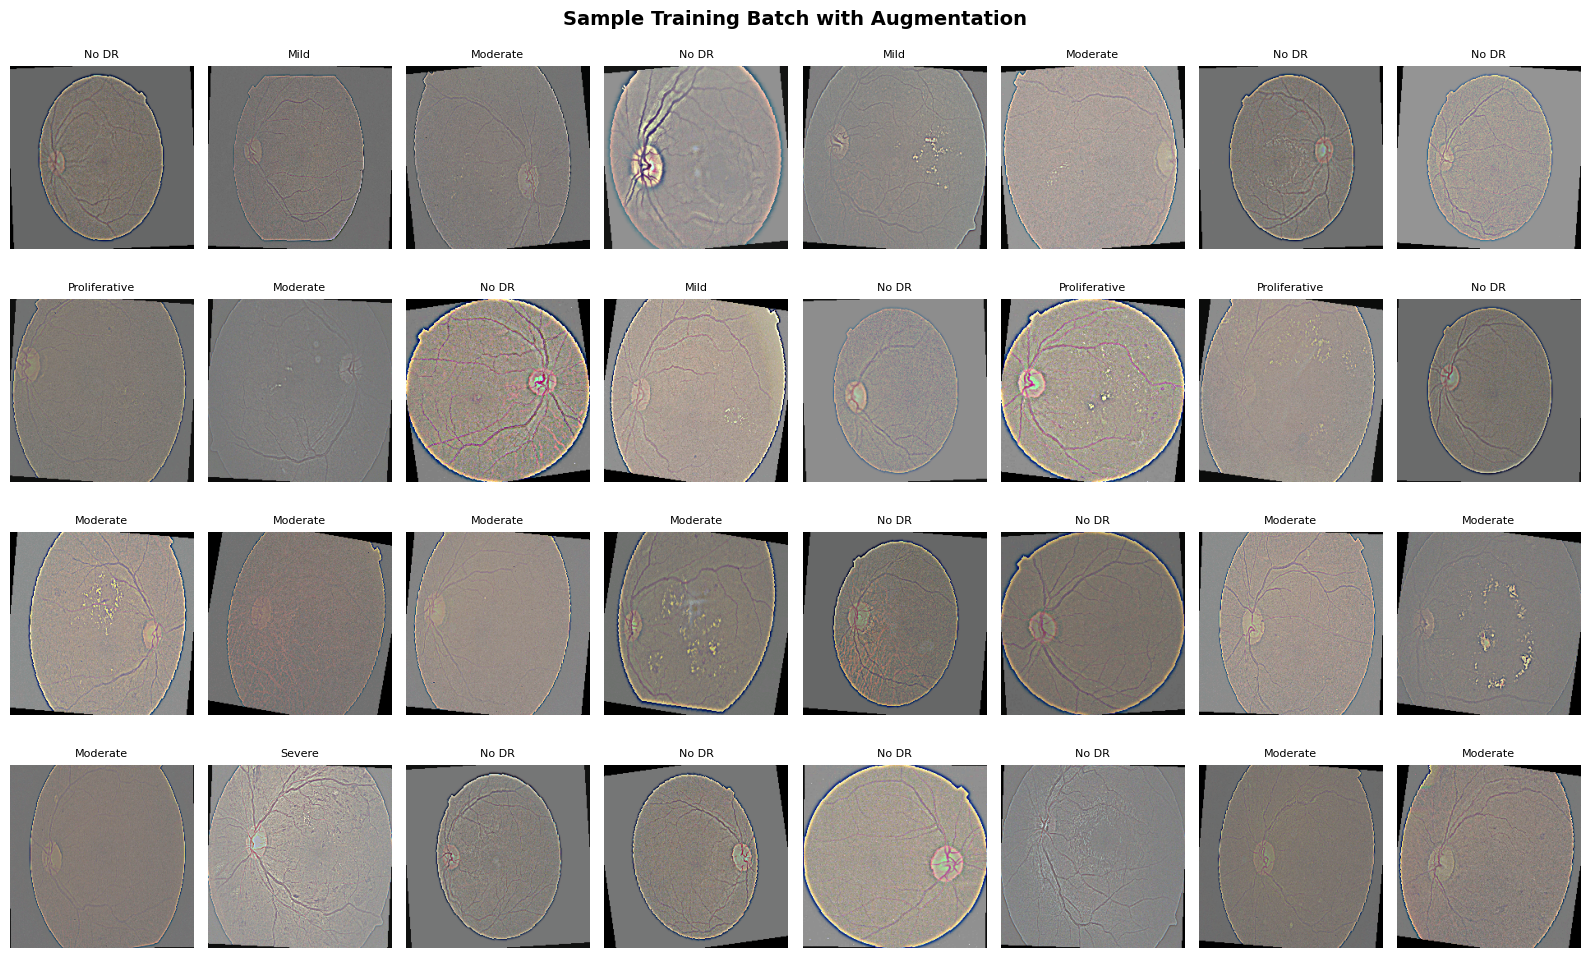

Saved: results/figures/batch_sample.png


In [7]:
# ============================================================================
# STEP 7: VISUALIZE A SAMPLE TRAINING BATCH
# ============================================================================

print("\n" + "=" * 70)
print("STEP 7: VISUALIZING TRAINING BATCH")
print("=" * 70)

def denormalize(tensor):
    """Reverse ImageNet normalization for display"""
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = tensor.permute(1, 2, 0).numpy()
    img = std * img + mean
    return np.clip(img, 0, 1)

# Get a batch of images
images, labels = next(iter(train_loader))

# Create figure
fig, axes = plt.subplots(4, 8, figsize=(16, 10))
fig.suptitle('Sample Training Batch with Augmentation', fontsize=14, fontweight='bold')

for i in range(min(32, len(images))):
    ax = axes[i // 8, i % 8]
    img = denormalize(images[i])
    ax.imshow(img)
    ax.set_title(f"{class_names[labels[i]]}", fontsize=8)
    ax.axis('off')

plt.tight_layout()

# Create results folder
os.makedirs('../results/figures', exist_ok=True)

# Save the figure
plt.savefig('../results/figures/batch_sample.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved: results/figures/batch_sample.png")

In [8]:
# ============================================================================
# STEP 8: CALCULATE CLASS WEIGHTS TO HANDLE IMBALANCE
# ============================================================================

print("\n" + "=" * 70)
print("STEP 8: HANDLING CLASS IMBALANCE")
print("=" * 70)

train_labels_array = np.array(train_labels)
classes = np.unique(train_labels_array)
weights = compute_class_weight('balanced', classes=classes, y=train_labels_array)
class_weights = torch.tensor(weights, dtype=torch.float)

print("\nClass weights (higher = more important for rare classes):")
print("-" * 60)
for i, name in enumerate(class_names):
    print(f"  {name:15}: {class_weights[i]:.4f}")

print("\nInterpretation:")
print("  - Proliferative DR (rare): higher weight = model pays more attention")
print("  - No DR (common): lower weight = model pays less attention")
print("  - This helps the model learn to detect severe cases")


STEP 8: HANDLING CLASS IMBALANCE

Class weights (higher = more important for rare classes):
------------------------------------------------------------
  No DR          : 0.4057
  Mild           : 1.9791
  Moderate       : 0.7332
  Severe         : 3.8039
  Proliferative  : 2.4822

Interpretation:
  - Proliferative DR (rare): higher weight = model pays more attention
  - No DR (common): lower weight = model pays less attention
  - This helps the model learn to detect severe cases


In [9]:
# ============================================================================
# STEP 9: SAVE PREPROCESSED DATA FOR TRAINING NOTEBOOK
# ============================================================================

print("\n" + "=" * 70)
print("STEP 9: SAVING PREPROCESSED DATA")
print("=" * 70)

# Create models folder
os.makedirs('../models', exist_ok=True)

# Save class weights
torch.save(class_weights, '../models/class_weights.pt')
print("Saved: models/class_weights.pt")

# Save split indices
torch.save({
    'train_idx': train_idx,
    'val_idx': val_idx,
    'class_names': class_names,
    'class_to_idx': {name: i for i, name in enumerate(class_names)}
}, '../models/split_indices.pt')
print("Saved: models/split_indices.pt")

# Save training configuration
config = {
    'batch_size': BATCH_SIZE,
    'img_size': IMG_SIZE,
    'random_seed': RANDOM_SEED,
    'train_split': 0.8,
    'class_names': class_names,
    'class_weights': class_weights.tolist()
}

with open('../models/training_config.json', 'w') as f:
    json.dump(config, f, indent=2)
print("Saved: models/training_config.json")


STEP 9: SAVING PREPROCESSED DATA
Saved: models/class_weights.pt
Saved: models/split_indices.pt
Saved: models/training_config.json


In [11]:
# ============================================================================
# STEP 10: FINAL SUMMARY
# ============================================================================

print("\n" + "=" * 70)
print("NOTEBOOK 02 COMPLETE")
print("=" * 70)

print("\nWHAT I ACCOMPLISHED:")
print("-" * 60)
print(f"1. Loaded APTOS dataset with correct ICDRSS labels")
print(f"   - Total images: {len(dataset)}")
print(f"   - Class order: {class_names}")
print(f"2. Created training set: {len(train_subset)} images (80%)")
print(f"3. Created validation set: {len(val_subset)} images (20%)")
print(f"4. Created data loaders with batch size {BATCH_SIZE}")
print(f"5. Applied augmentation to training data only")
print(f"6. Calculated class weights to handle imbalance")
print(f"7. Saved: class_weights.pt, split_indices.pt, training_config.json")

print("\nCLASS DISTRIBUTION:")
print("-" * 60)

# Convert tensors to lists for counting
train_labels_list = train_labels.tolist() if hasattr(train_labels, 'tolist') else list(train_labels)
val_labels_list = val_labels.tolist() if hasattr(val_labels, 'tolist') else list(val_labels)

for i, name in enumerate(class_names):
    train_count = train_labels_list.count(i)
    val_count = val_labels_list.count(i)
    total_count = class_counts.get(i, 0)
    print(f"  {name:15}: Total: {total_count:4}, Train: {train_count:4}, Val: {val_count:4}")

print("\n" + "=" * 70)
print("NEXT: Open Notebook 03 - Model Training")
print("=" * 70)


NOTEBOOK 02 COMPLETE

WHAT I ACCOMPLISHED:
------------------------------------------------------------
1. Loaded APTOS dataset with correct ICDRSS labels
   - Total images: 3662
   - Class order: ['No DR', 'Mild', 'Moderate', 'Severe', 'Proliferative']
2. Created training set: 2929 images (80%)
3. Created validation set: 733 images (20%)
4. Created data loaders with batch size 32
5. Applied augmentation to training data only
6. Calculated class weights to handle imbalance
7. Saved: class_weights.pt, split_indices.pt, training_config.json

CLASS DISTRIBUTION:
------------------------------------------------------------
  No DR          : Total: 1805, Train: 1444, Val:   20
  Mild           : Total:  370, Train:  296, Val:    4
  Moderate       : Total:  999, Train:  799, Val:    3
  Severe         : Total:  193, Train:  154, Val:    4
  Proliferative  : Total:  295, Train:  236, Val:    1

NEXT: Open Notebook 03 - Model Training
